## Homework: AI Orchestration with Kestra

> It's possible your answers won't match exactly. If so, select the closest one

## Prerequisites

Before starting this homework, ensure you have:

1. Completed the [Module 3 lessons](../../../03-orchestration/README.md) — the questions reference flows and concepts covered there
2. Kestra running locally with API keys configured (see the [Setup](../../../03-orchestration/lessons/03-setup.md) lesson) -- this includes the Gemini API key, which is also required for the AI Copilot
3. Imported all flows from the `03-orchestration/flows/` directory (covered in the Setup lesson)

## Question 1: Context Engineering

Try the following experiment:

1. Open ChatGPT in a private browser window: https://chatgpt.com
2. Enter this prompt: "Create a Kestra flow that loads NYC taxi data from CSV to BigQuery"
3. Then, use Kestra's AI Copilot with the same prompt

After trying the same prompt in ChatGPT vs Kestra's AI Copilot, what is the primary reason AI Copilot generates better Kestra flows?

- AI Copilot uses a more powerful model
- AI Copilot has access to current Kestra plugin documentation
- AI Copilot uses more tokens
- AI Copilot has internet access

### Answer
- AI Copilot has access to current Kestra plugin documentation

Output from Kestra's AI Copilot: [flows/hw3_ai_copilot.yaml](flows/hw3_ai_copilot.yaml)

Output from ChatGPT: [flows/hw3_chatgpt.yaml](flows/hw3_chatgpt.yaml)

## Question 2: RAG Comparison

Run both `1_chat_without_rag.yaml` and `2_chat_with_rag.yaml` in the Kestra UI. Read the execution logs for each.

The non-RAG response about Kestra 1.1 features is best described as:

- Accurate and specific, matching the actual release notes
- Vague, generic, or fabricated — the model guesses from training data
- Empty — the model refuses to answer without context
- Identical to the RAG version

### Answer
- Vague, generic, or fabricated — the model guesses from training data

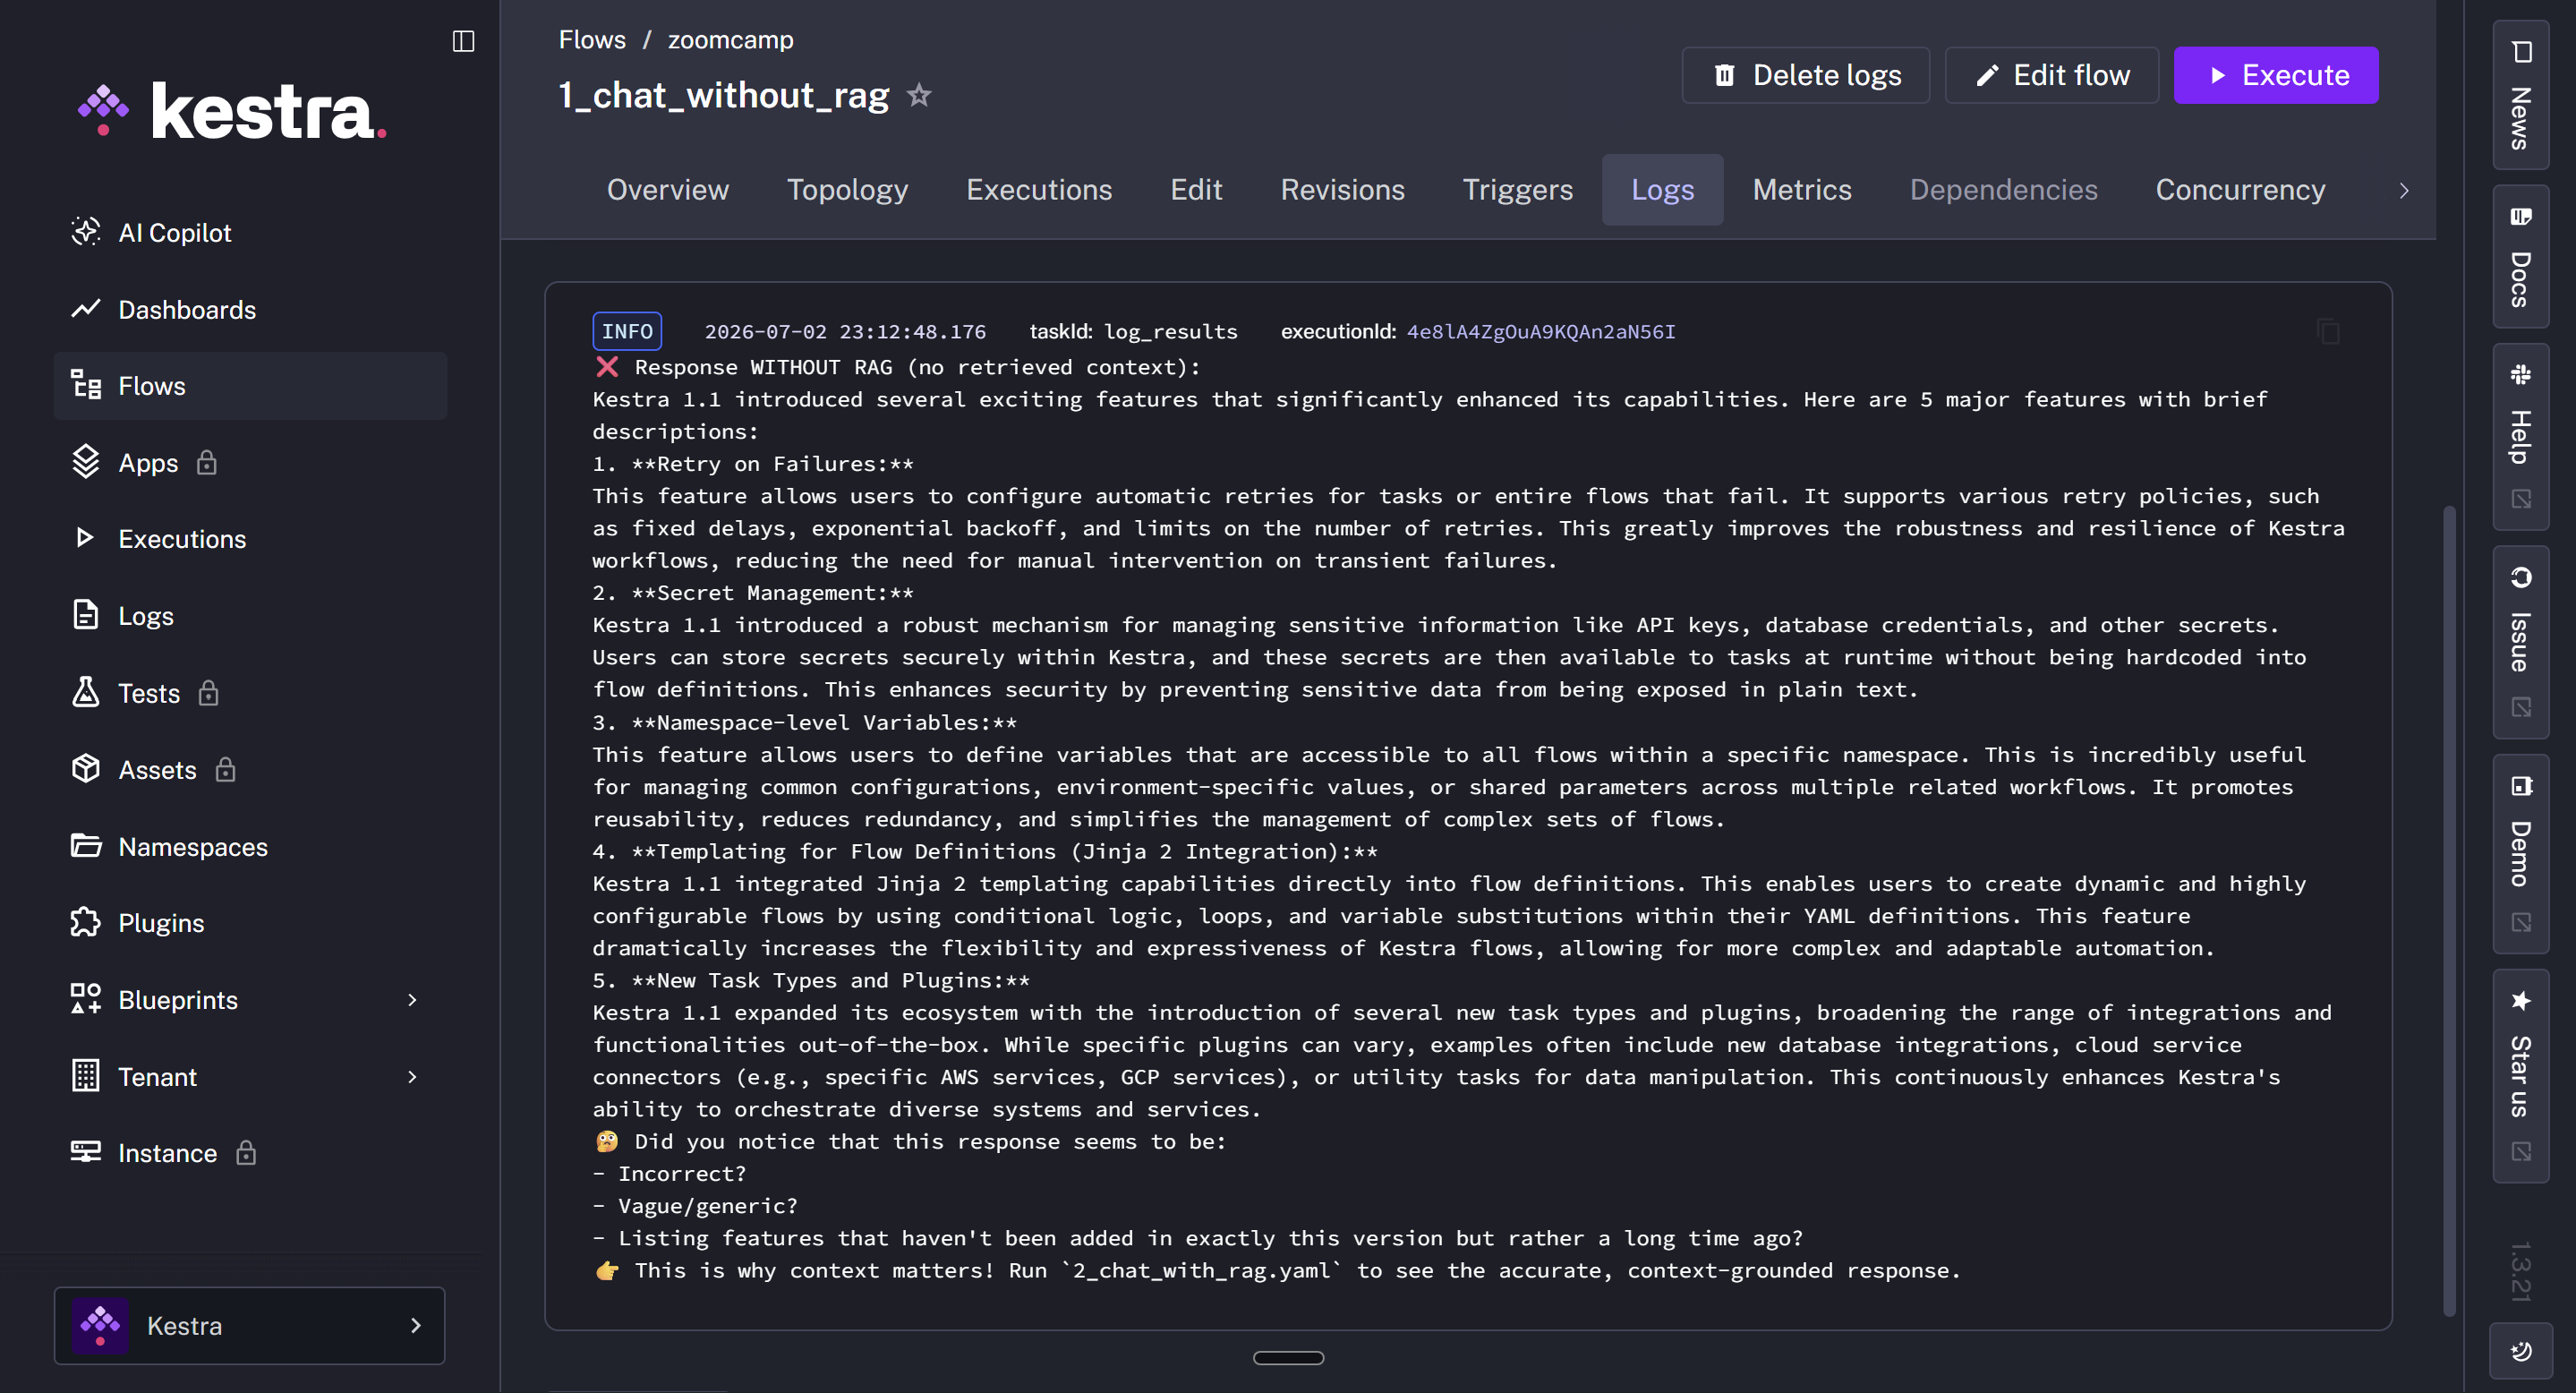

#### Execution logs for 1_chat_without_rag.yaml:

INFO 2026-07-02T15:12:48.176277Z ❌ Response WITHOUT RAG (no retrieved context):
Kestra 1.1 introduced several exciting features that significantly enhanced its capabilities. Here are 5 major features with brief descriptions:

1.  **Retry on Failures:**
    This feature allows users to configure automatic retries for tasks or entire flows that fail. It supports various retry policies, such as fixed delays, exponential backoff, and limits on the number of retries. This greatly improves the robustness and resilience of Kestra workflows, reducing the need for manual intervention on transient failures.

2.  **Secret Management:**
    Kestra 1.1 introduced a robust mechanism for managing sensitive information like API keys, database credentials, and other secrets. Users can store secrets securely within Kestra, and these secrets are then available to tasks at runtime without being hardcoded into flow definitions. This enhances security by preventing sensitive data from being exposed in plain text.

3.  **Namespace-level Variables:**
    This feature allows users to define variables that are accessible to all flows within a specific namespace. This is incredibly useful for managing common configurations, environment-specific values, or shared parameters across multiple related workflows. It promotes reusability, reduces redundancy, and simplifies the management of complex sets of flows.

4.  **Templating for Flow Definitions (Jinja 2 Integration):**
    Kestra 1.1 integrated Jinja 2 templating capabilities directly into flow definitions. This enables users to create dynamic and highly configurable flows by using conditional logic, loops, and variable substitutions within their YAML definitions. This feature dramatically increases the flexibility and expressiveness of Kestra flows, allowing for more complex and adaptable automation.

5.  **New Task Types and Plugins:**
    Kestra 1.1 expanded its ecosystem with the introduction of several new task types and plugins, broadening the range of integrations and functionalities out-of-the-box. While specific plugins can vary, examples often include new database integrations, cloud service connectors (e.g., specific AWS services, GCP services), or utility tasks for data manipulation. This continuously enhances Kestra's ability to orchestrate diverse systems and services.

🤔 Did you notice that this response seems to be:
- Incorrect?
- Vague/generic?
- Listing features that haven't been added in exactly this version but rather a long time ago?

👉 This is why context matters! Run `2_chat_with_rag.yaml` to see the accurate, context-grounded response.


#### Execution logs for 2_chat_with_rag.yaml

INFO 2026-07-02T15:12:32.692952Z ✅ RAG Response (with retrieved context):
Here are 5 major features released in Kestra 1.1:

1.  **New Filters**: The UI filters across Kestra have been completely redesigned for improved usability. Users can now choose from explicit options, reset filters with a single click, save frequently used combinations, and customize table column visibility.
2.  **No-Code Dashboard Editor**: Kestra 1.1 introduced a no-code, multi-panel editor for custom dashboards. This allows users to build and customize dashboards directly from the UI using form-based tabs for data sources, visualizations, and charts, without needing to write YAML.
3.  **Human Task**: This new feature enables human-in-the-loop workflows for Enterprise Edition users. It allows executions to be paused and require manual approval from specific users or groups before proceeding, which is useful for validation steps in critical workflows.
4.  **Multi-Agent AI Systems**: AI agents can now use other AI agents as tools, facilitating sophisticated multi-agent orchestration workflows. This allows a primary agent to delegate subtasks to specialized expert agents, creating hierarchies of AI reasoning.
5.  **Fix with AI**: Kestra 1.1 introduced AI-powered suggestions for failed task runs. When a task fails, the "Fix with AI" feature analyzes the run and provides intelligent recommendations to help users diagnose and resolve issues faster.

🎉 Note that this response is detailed, accurate, and grounded in the actual release documentation. Compare this with the output from 1_chat_without_rag.yaml!


## Question 3: Token usage — short summary

Run `4_simple_agent.yaml` with `summary_length = short` (leave the other inputs as defaults).

Open the execution logs and find the token usage logged by the `log_token_usage` task.

What is the approximate **output** token count for `multilingual_agent`?

- 5-15 tokens
- 60-100 tokens
- 200-400 tokens
- 500+ tokens

### Answer
- 60-100 tokens

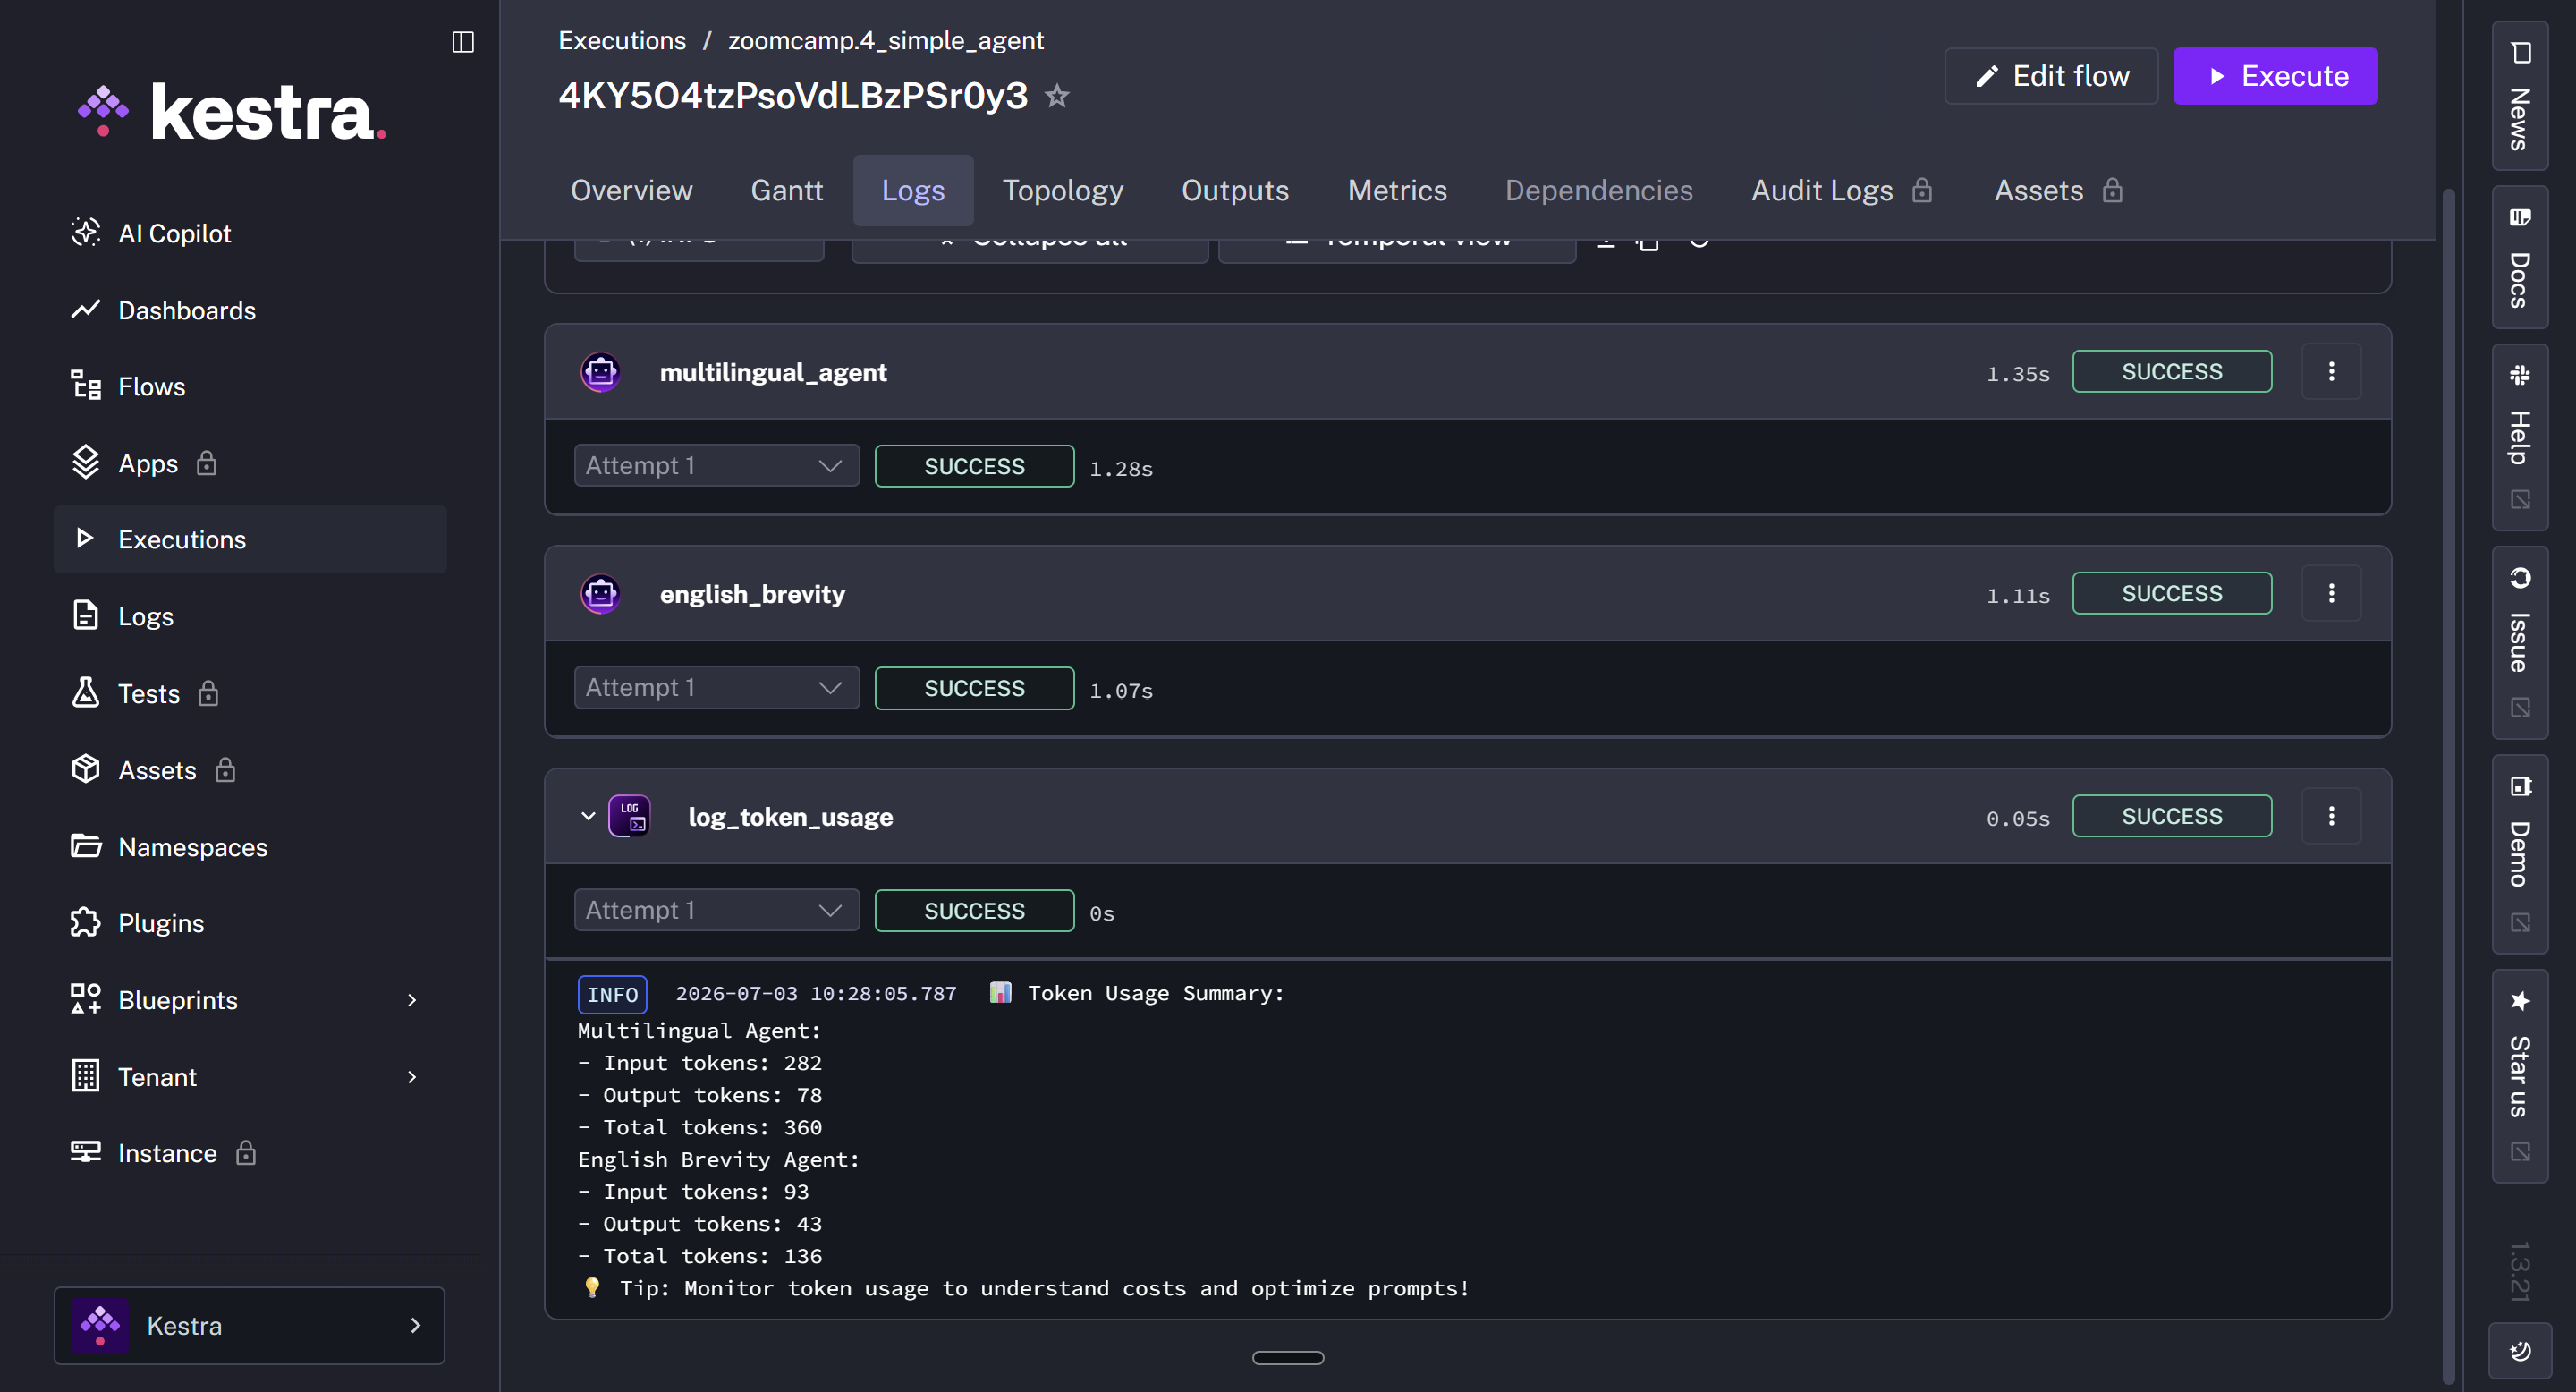

INFO 2026-07-03T02:28:05.787443Z 📊 Token Usage Summary:

Multilingual Agent:
- Input tokens: 282
- Output tokens: 78
- Total tokens: 360

English Brevity Agent:
- Input tokens: 93
- Output tokens: 43
- Total tokens: 136

💡 Tip: Monitor token usage to understand costs and optimize prompts!


## Question 4: Token usage — long summary

Run `4_simple_agent.yaml` again with `summary_length = long`.

Compare the `multilingual_agent` output token count to your result from Question 3. Roughly how many times more output tokens does the long summary use?

- About the same (within 20%)
- 2-5x more
- 10-20x more
- 50x more

### Answer
- About the same (within 20%)

INFO 2026-07-03T02:28:00.180866Z 📊 Token Usage Summary:

Multilingual Agent:
- Input tokens: 282
- Output tokens: 213
- Total tokens: 495

English Brevity Agent:
- Input tokens: 228
- Output tokens: 51
- Total tokens: 279

💡 Tip: Monitor token usage to understand costs and optimize prompts!


In [1]:
51 / 43

1.186046511627907

## Question 5: Modifying a flow

Open `4_simple_agent.yaml` in the Kestra flow editor. Find the `english_brevity` task and change its prompt from asking for exactly **1 sentence** to asking for exactly **3 sentences**.

Save the flow, then run it with `summary_length = long`.

Compare the `english_brevity` output token count to the original 1-sentence version (also with `summary_length = long`). How do they compare?

- About the same (within 20%)
- 2-4x more
- 5-10x more
- 10x+ more

### Answer
- 2-5x more

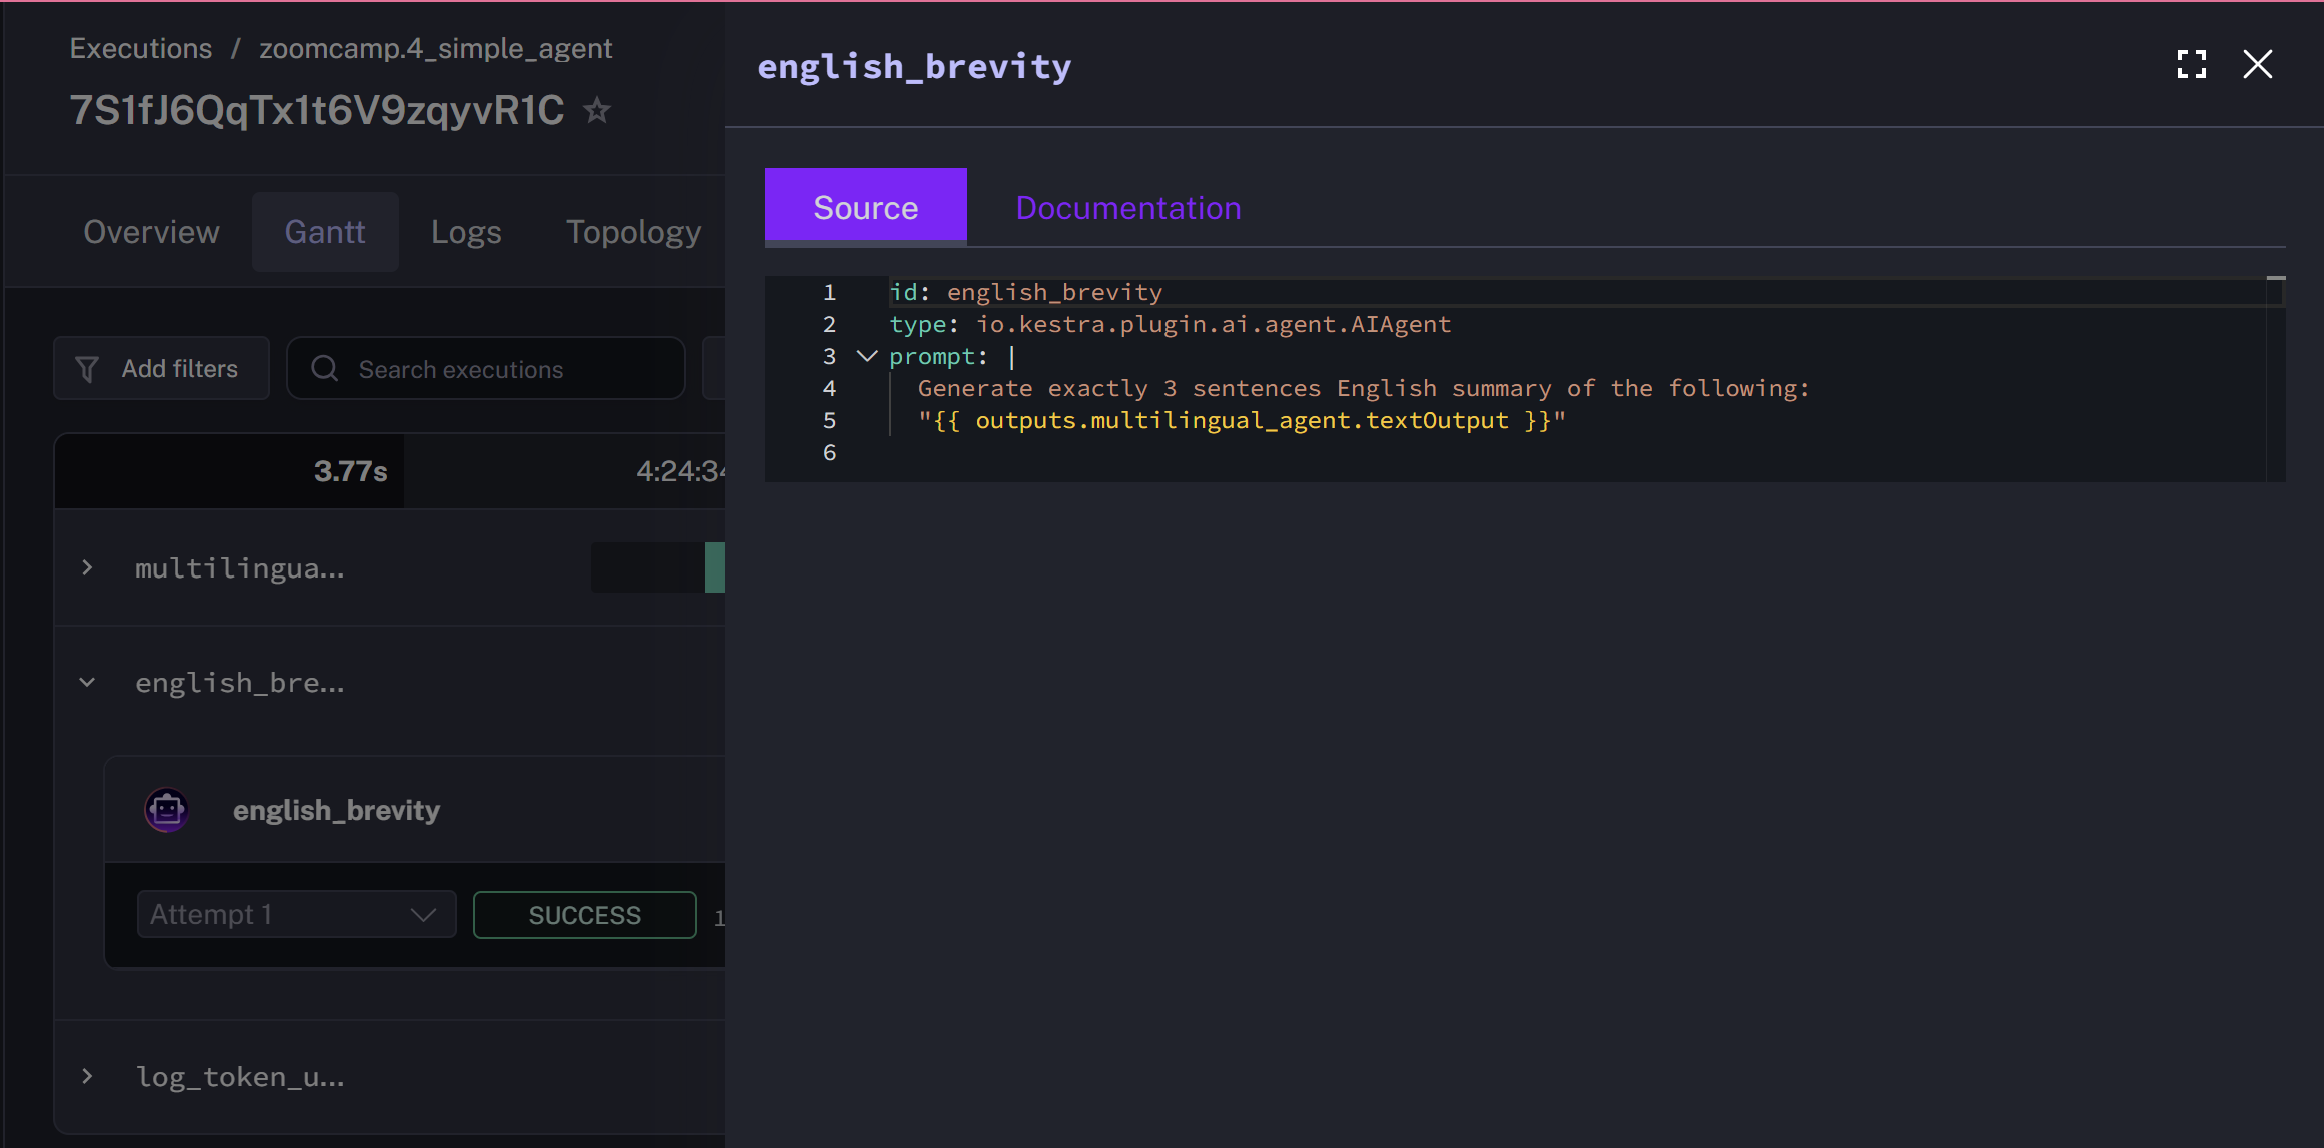

INFO 2026-07-03T08:24:38.479643Z 📊 Token Usage Summary:

Multilingual Agent:
- Input tokens: 282
- Output tokens: 180
- Total tokens: 462

English Brevity Agent:
- Input tokens: 195
- Output tokens: 101
- Total tokens: 296

💡 Tip: Monitor token usage to understand costs and optimize prompts!


In [2]:
101 / 51

1.9803921568627452

## Question 6: Best Practices

Based on what you learned in this module, for production workflows requiring deterministic, repeatable results with strict compliance requirements (e.g., financial reporting, workflows in highly regulated industries), which approach is most appropriate?

- Always use AI agents for maximum flexibility and adaptation
- Use traditional task-based workflows for predictability and auditability
- Use only RAG without agents for better performance
- Use web search tools exclusively to ensure current data

### Answer
- Use traditional task-based workflows for predictability and auditability